# Cancer Detection

## PART 1 - Project description
The project uses deep learning techniques to classify images as cancerous or non-cancerous. 

In the first step, we import Python libraries, sample an equal number of cancer- and non-cancer-related images, transform and randomly rotate images, flip them vertically and horizontally, and select images for the model's training, testing, and validation sets. 

In the second step, we implement an EfficientNet with pre-trained weights, train it on the training set, validate it on the validation set, and evaluate its performance on the test dataset. 

In the third step, we build a simple, custom EfficientNet from scratch, train it, and evaluate its performance. 

Finally, we compare the performance of the pre-trained EfficientNet with that of the custom model

Note: The end of the code produces the prediction.csv file needed to submitt to competition


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Student - FP

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         os.path.join(dirname, filename)
        
all_files = []
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        path = os.path.join(dirname, filename)
        all_files.append(path)

print("cell executed")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

cell executed


In [2]:
# system packages
import os
import zipfile
import copy

# ML packages
import pandas as pd
from sklearn.model_selection import train_test_split

# # torch 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# torchvision
import torchvision
from torchvision import transforms, models

# # image processing packages
from PIL import Image
from tqdm import tqdm

# visualization packages
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

from datetime import date

print("cell executed: ", date.today())

Torch version: 2.8.0+cu126
Torchvision version: 0.23.0+cu126
cell executed:  2026-03-15


## PART 2 - Exploratory Data Analysis

In [3]:
index_to_labels_mapping = {
    0: "No Cancer",
    1: "Cancer"
}

print(index_to_labels_mapping)

print("cell executed: ", date.today())

{0: 'No Cancer', 1: 'Cancer'}
cell executed:  2026-03-15


In [4]:
train_images_root_dir = '/kaggle/input/histopathologic-cancer-detection/train'
df = pd.read_csv('/kaggle/input/histopathologic-cancer-detection/train_labels.csv')
print(df.head())

print("cell executed: ", date.today())


                                         id  label
0  f38a6374c348f90b587e046aac6079959adf3835      0
1  c18f2d887b7ae4f6742ee445113fa1aef383ed77      1
2  755db6279dae599ebb4d39a9123cce439965282d      0
3  bc3f0c64fb968ff4a8bd33af6971ecae77c75e08      0
4  068aba587a4950175d04c680d38943fd488d6a9d      0
cell executed:  2026-03-15


In [5]:
img_path = os.path.join(train_images_root_dir, df["id"].values[0]+".tif")
img = Image.open(img_path)
print("Mode:", img.mode)  # 'L' -> grayscale, 'RGB' -> color, 

to_tensor = transforms.ToTensor()
img_tensor = to_tensor(img)  # shape: [C, H, W]
img_tensor.shape

print("cell executed: ", date.today())


Mode: RGB
cell executed:  2026-03-15


In [6]:
df_class_0 = df[df['label'] == 0].sample(n=5000, random_state=42)
df_class_1 = df[df['label'] == 1].sample(n=5000, random_state=42)

df_sampled = pd.concat([df_class_0, df_class_1]).reset_index(drop=True)
print(df_sampled.head())

print("cell executed: ", date.today())

                                         id  label
0  941ffe73059292e0effd4e81ca9363c117afc2f4      0
1  43b6acadb31161c9281460efa3fad0b992a92837      0
2  64cfb56ddf41e2a871ac5164d61e50b238b9ed1b      0
3  9464cf403653088420cdb78acacd8cf7fa2255e4      0
4  346bc5b2d383d70dfccb8fe9102c7f55687f5f52      0
cell executed:  2026-03-15


In [7]:
filenames = [f"{id}.tif" for id in df_sampled['id']]
print(len(filenames), '\n', filenames[0], '\n', filenames[-1])

print("cell executed: ", date.today())

10000 
 941ffe73059292e0effd4e81ca9363c117afc2f4.tif 
 432e46bbf8e5ecb4bf0941f9b3584315280ecfe8.tif
cell executed:  2026-03-15


In [8]:
# train and test
# 60% for data train and 40% for test & validation
train_df, val_test_df = train_test_split(df_sampled, 
                                     test_size=0.4, 
                                     stratify=df_sampled['label'], 
                                     random_state=42)

# 20% for test and 20% for validation
val_df, test_df = train_test_split(val_test_df, 
                                   test_size=0.5, 
                                   stratify=val_test_df['label'], 
                                   random_state=42)

print("cell executed: ", date.today())

cell executed:  2026-03-15


In [9]:
# reset indices
train_df.reset_index(drop=True)
val_df.reset_index(drop=True)
test_df.reset_index(drop=True)

print(f"Train: {len(train_df)}, \
      Validation: {len(val_df)}, \
      Test: {len(test_df)}")

print("cell executed: ", date.today())

Train: 6000,       Validation: 2000,       Test: 2000
cell executed:  2026-03-15


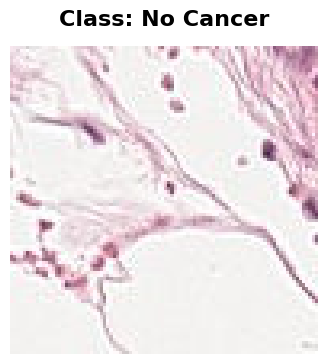

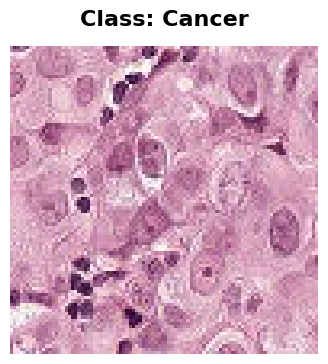

cell executed:  2026-03-15


In [10]:
def plot_image_from_train(label=0):
    df_random = train_df[train_df.label==label].sample(1)
    filename = df_random["id"].values[0]
    file_path = os.path.join(train_images_root_dir, filename + ".tif")

    img = Image.open(file_path)

    plt.figure(figsize=(4, 4)) 
    plt.imshow(img)
    plt.axis('off')  
    plt.title(f"Class: {index_to_labels_mapping[label]}",
              fontsize=16,
              fontweight='bold',
              pad=15)
    plt.show()

plot_image_from_train(label=0)
plot_image_from_train(label=1)

print("cell executed: ", date.today())


In [11]:
class CancerDataset():
    def __init__(self, df, root_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, 
                                f"{self.df.iloc[idx]['id']}.tif")
        image = Image.open(img_name)
        label = self.df.iloc[idx]['label']
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

print("cell executed: ", date.today())


cell executed:  2026-03-15


In [12]:
# Image transformation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=90),
    
    transforms.ToTensor(),
    # transforms.Pad(padding=64, fill=0), # 96 + 128 = 224; as resnet requires input at 3 channel * 224 * 224 W H
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Pad(padding=64, fill=0), # 96 + 128 = 224; as resnet requires input at 3 channel * 224 * 224 W H
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Pad(padding=64, fill=0), # 96 + 128 = 224; as resnet requires input at 3 channel * 224 * 224 W H
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("cell executed: ", date.today())

cell executed:  2026-03-15


In [13]:
train_dataset = CancerDataset(train_df, 
                              train_images_root_dir, 
                              transform=train_transform)

val_dataset = CancerDataset(val_df,
                            train_images_root_dir,
                            transform=val_transform)

test_dataset = CancerDataset(test_df,
                             train_images_root_dir,
                             transform=test_transform)

print("cell executed: ", date.today())


cell executed:  2026-03-15


In [14]:
# first image in train dataset
image, label = train_dataset[0]
print("Image shape:", image.shape)
print("Label:", label)

print("cell executed: ", date.today())

Image shape: torch.Size([3, 96, 96])
Label: 1
cell executed:  2026-03-15


In [16]:
batch_size = 256

train_dl = DataLoader(train_dataset, 
                      batch_size=batch_size, 
                      shuffle=True, 
                      num_workers=4, 
                      pin_memory=True)

val_dl = DataLoader(val_dataset, 
                    batch_size=batch_size, 
                    shuffle=False, 
                    num_workers=4, 
                    pin_memory=True)

test_dl = DataLoader(test_dataset, 
                     batch_size=batch_size, 
                     shuffle=False, 
                     num_workers=4, 
                     pin_memory=True)

print("cell executed: ", date.today())


cell executed:  2026-03-15


In [17]:
# COURTESSY TO JOVIAN.AI
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')
    
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl: 
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

print("cell executed: ", date.today())

cell executed:  2026-03-15


In [18]:
device = get_default_device()
print(device)

print("cell executed: ", date.today())

cuda
cell executed:  2026-03-15


In [19]:
train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
test_dl = DeviceDataLoader(test_dl, device)

print("cell executed: ", date.today())

cell executed:  2026-03-15


## PART 3 - Model building; Efficient Net

EfficientNet is a family of highly efficient convolutional neural networks (CNNs) developed by Google AI that achieves state-of-the-art accuracy in image classification while using significantly fewer parameters and computational resources (FLOPS) than traditional CNNs.  

EfficientNet models offer superior accuracy with significantly fewer parameters and lower computational costs (FLOPs) compared to traditional CNNs, largely due to a balanced "compound scaling" method that uniformly scales network depth, width, and resolution. They are highly efficient, faster at inference, and ideal for mobile, edge, or resource-constrained deployments. 

Key advantages of using EfficientNet include:

- State-of-the-Art Accuracy & Efficiency: EfficientNet achieves better performance than heavier models like ResNet or Inception on datasets like ImageNet, while being up to 8x smaller and 6x faster on CPU inference.
- Compound Scaling Method: Instead of arbitrarily scaling network dimensions, EfficientNet uses a fixed formula to balance depth, width, and resolution, maximizing efficiency.
- Ideal for Edge Deployment: Due to low parameter counts and reduced computational load, models like EfficientNet-B0 are perfect for real-time applications on mobile devices and edge, says a Reddit post and a blog post.
- High Generalization (Transfer Learning): The models transfer well to other datasets, making them excellent, high-accuracy backbones for specialized tasks like medical image analysis or object detection.
- Comprehensive Model Family (B0-B7): The architecture offers a wide range of models, allowing developers to pick the right balance of speed and accuracy for their specific hardware constraint.


In [20]:
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

# Initialize V2-Scmall with the latest available pretrained weights
model = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.DEFAULT)

# classifier for binary classification
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)

print(model.classifier)

print("cell executed: ", date.today())

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 150MB/s] 


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)
cell executed:  2026-03-15


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)
model = model.to(device)

print("cell executed: ", date.today())

Using 2 GPUs
cell executed:  2026-03-15


In [22]:
# same for Efficnet Net as wll as for the customized models
patience = 8  # epochs to wait for improvement for early stopping
num_epochs = 30

print("cell executed: ", date.today())

cell executed:  2026-03-15


In [23]:
criterion = nn.CrossEntropyLoss()

# set the learning rate for the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.0001) 

# reduce learing rate by a factor of 0.9 every 5 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.9)

best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
early_stop_counter = 0

train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for inputs, labels in train_dl:
        optimizer.zero_grad()
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
        predicted = outputs.argmax(dim=1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss /= len(train_dataset)
    train_acc = 100 * train_correct / train_total

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    model.eval()
    
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in val_dl:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            predicted = outputs.argmax(dim=1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss /= len(val_dataset)
    val_acc = 100 * val_correct / val_total
    
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    scheduler.step()
    
    # early stopping to prevent overfitting
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"Early stop after {epoch+1} epochs")
            break

# load best weights after training
model.load_state_dict(best_model_wts)

print("cell executed: ", date.today())


Epoch 1/30 - Train Loss: 0.5652, Train Acc: 71.62% - Val Loss: 0.4388, Val Acc: 79.95%
Epoch 2/30 - Train Loss: 0.4017, Train Acc: 81.72% - Val Loss: 0.3756, Val Acc: 83.25%
Epoch 3/30 - Train Loss: 0.3392, Train Acc: 85.08% - Val Loss: 0.3327, Val Acc: 86.15%
Epoch 4/30 - Train Loss: 0.3034, Train Acc: 86.97% - Val Loss: 0.2998, Val Acc: 87.90%
Epoch 5/30 - Train Loss: 0.2728, Train Acc: 88.72% - Val Loss: 0.2656, Val Acc: 89.10%
Epoch 6/30 - Train Loss: 0.2551, Train Acc: 89.55% - Val Loss: 0.2709, Val Acc: 89.15%
Epoch 7/30 - Train Loss: 0.2411, Train Acc: 89.98% - Val Loss: 0.2584, Val Acc: 89.75%
Epoch 8/30 - Train Loss: 0.2191, Train Acc: 91.33% - Val Loss: 0.2438, Val Acc: 90.25%
Epoch 9/30 - Train Loss: 0.2094, Train Acc: 91.58% - Val Loss: 0.2362, Val Acc: 90.75%
Epoch 10/30 - Train Loss: 0.2001, Train Acc: 92.07% - Val Loss: 0.2375, Val Acc: 90.75%
Epoch 11/30 - Train Loss: 0.1960, Train Acc: 92.42% - Val Loss: 0.2198, Val Acc: 91.65%
Epoch 12/30 - Train Loss: 0.1690, Train A

In [24]:
training_statistics = pd.DataFrame({"Training_Accuracy": train_accs,
                               "Training_Loss": train_losses,
                               "Val_Loss": val_losses,
                               "Val_Accuracy": val_accs})

n_epochs = len(training_statistics)

print("cell executed: ", date.today())


cell executed:  2026-03-16


In [25]:
print("Training statistics:\n", training_statistics)
print("Smallest loss: ", best_val_loss)

print("cell executed: ", date.today())


Training statistics:
     Training_Accuracy  Training_Loss  Val_Loss  Val_Accuracy
0           71.616667       0.565176  0.438752         79.95
1           81.716667       0.401667  0.375577         83.25
2           85.083333       0.339173  0.332673         86.15
3           86.966667       0.303415  0.299849         87.90
4           88.716667       0.272828  0.265590         89.10
5           89.550000       0.255116  0.270884         89.15
6           89.983333       0.241125  0.258425         89.75
7           91.333333       0.219147  0.243772         90.25
8           91.583333       0.209431  0.236236         90.75
9           92.066667       0.200094  0.237453         90.75
10          92.416667       0.195981  0.219808         91.65
11          93.483333       0.169036  0.232568         91.50
12          93.400000       0.166853  0.218152         92.05
13          93.666667       0.166437  0.218553         91.30
14          94.500000       0.147185  0.223626         92.30
15

cell executed:  2026-03-16


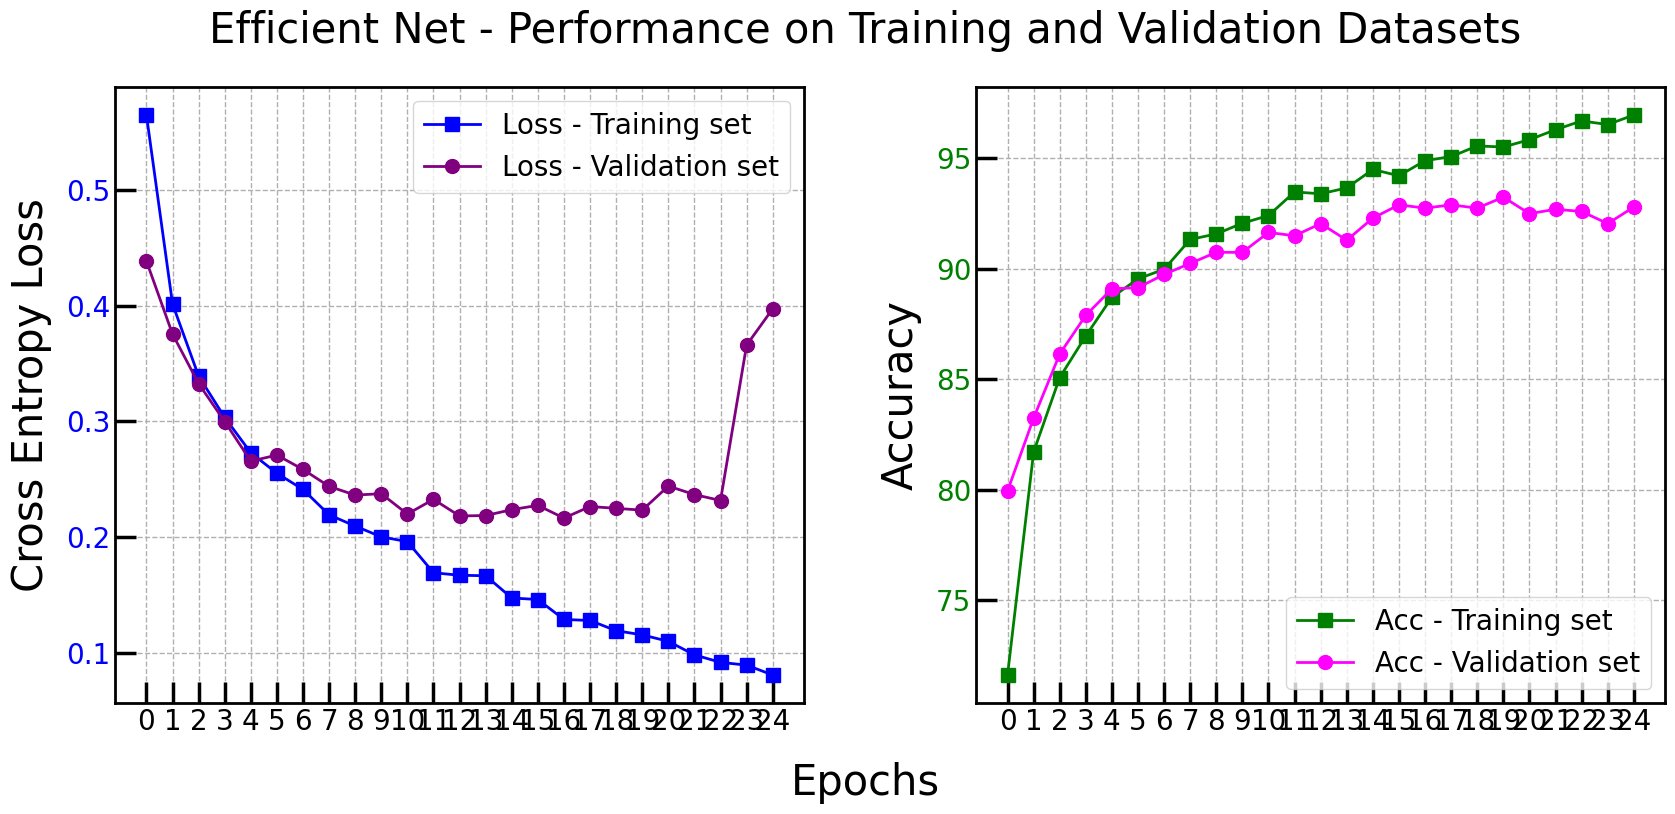

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
ax1 = plt.subplot(1,2, 1)

plot_1 = ax1.plot(range(n_epochs), 
                  training_statistics['Training_Loss'], 
                  color = 'blue', 
                  label = 'Loss - Training set',
                  marker = 's',
                  linewidth=2.0,
                  markersize = 10)

plot_2 = ax1.plot(range(n_epochs),
                  training_statistics['Val_Loss'],
                  color = 'purple',
                  label = 'Loss - Validation set',
                  marker = 'o',
                  linewidth=2.0,
                  markersize = 10)

ax1.legend(fontsize = 20)
plt.xticks(range(0, n_epochs, 1))
ax1.tick_params(axis ='y', labelcolor = 'blue',labelsize=20, width=3) 
ax1.tick_params(axis ='x', labelcolor = 'black',labelsize=20, width=3)
ax1.set_ylabel("Cross Entropy Loss", fontsize = 30, labelpad = 10, color = 'black')


ax1a = plt.subplot(1,2, 2)
plot_11 = ax1a.plot(range(n_epochs),
                    training_statistics['Training_Accuracy'],
                    color = 'green',
                    label = 'Acc - Training set',
                    marker = 's',
                    linewidth=2.0,
                    markersize = 10)

plot_22 = ax1a.plot(range(n_epochs),
                    training_statistics['Val_Accuracy'],
                    color = 'fuchsia',
                    label = 'Acc - Validation set',
                    marker = 'o',
                    linewidth=2.0,
                    markersize = 10)

ax1a.legend(fontsize = 20)
plt.xticks(range(0,n_epochs,1))
ax1a.tick_params(axis ='y', labelcolor = 'green',labelsize=20, width=3) 
ax1a.tick_params(axis ='x', labelcolor = 'black',labelsize=20, width=3)
ax1a.set_ylabel("Accuracy", fontsize = 30, labelpad = 10, color = 'black')

ax1.tick_params(which='both', width=2.5)
ax1.tick_params(which='major', length=15)
ax1.tick_params(which='minor', length=5)
ax1.tick_params(which = 'both', direction = 'in')

ax1a.tick_params(which='both', width=2.5)
ax1a.tick_params(which='major', length=15)
ax1a.tick_params(which='minor', length=5)
ax1a.tick_params(which = 'both', direction = 'in') 

ax1a.spines['bottom'].set_color('black')
ax1a.spines['top'].set_color('black') 
ax1a.spines['right'].set_color('black')
ax1a.spines['right'].set_linewidth(2)
ax1a.spines['top'].set_linewidth(2)
ax1a.spines['bottom'].set_linewidth(2)
ax1a.spines['left'].set_color('black')
ax1a.spines['left'].set_lw(2)

ax1.spines['bottom'].set_color('black')
ax1.spines['top'].set_color('black') 
ax1.spines['right'].set_color('black')
ax1.spines['right'].set_linewidth(2)
ax1.spines['top'].set_linewidth(2)
ax1.spines['bottom'].set_linewidth(2)
ax1.spines['left'].set_color('black')
ax1.spines['left'].set_lw(2)

ax1.grid(True, which = 'major', alpha = 1, linestyle='--', linewidth = 1)
ax1a.grid(True, which = 'major', alpha = 1, linestyle='--', linewidth = 1)

plt.subplots_adjust(wspace=0.25,hspace=0.)
fig.text(0.5, 0.01, 
         'Epochs', 
         ha='center', 
         va='center', 
         fontsize = 30)

fig.text(0.5, 0.95,
         'Efficient Net - Performance on Training and Validation Datasets',
         ha='center', 
         va='center', 
         fontsize = 30)

print("cell executed: ", date.today())


In [27]:
def get_test_predictions_with_probs(best_model, dataloader, device="cuda"):
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = best_model(inputs)  
            probs = F.softmax(outputs, dim=1)  # convert logits to probabilities with softmax
            predicted = outputs.argmax(dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return all_labels, all_preds, all_probs

print("cell executed: ", date.today())


cell executed:  2026-03-16


In [28]:
%%time

train_actuals, train_pred, train_pred_proba = get_test_predictions_with_probs(model, train_dl)

print("cell executed: ", date.today())


100%|██████████| 24/24 [00:08<00:00,  2.92it/s]

cell executed:  2026-03-16
CPU times: user 5.62 s, sys: 521 ms, total: 6.15 s
Wall time: 8.22 s


In [29]:
val_actuals, val_pred, val_pred_proba = get_test_predictions_with_probs(model, val_dl)
test_actuals, test_pred, test_pred_proba = get_test_predictions_with_probs(model, test_dl)

print("cell executed: ", date.today())


100%|██████████| 8/8 [00:04<00:00,  1.79it/s]

cell executed:  2026-03-16


In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, roc_curve 

print("cell executed: ", date.today())


cell executed:  2026-03-16


In [31]:
print("The testing accuracy is: {}".format(round(accuracy_score(train_actuals, train_pred)*100, 2)))
print("cell executed: ", date.today())


The testing accuracy is: 96.77
cell executed:  2026-03-16


In [32]:
print("Classification report for training set")
print(classification_report(train_actuals, train_pred))
print("cell executed: ", date.today())

Classification report for training set
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      3000
           1       0.97      0.96      0.97      3000

    accuracy                           0.97      6000
   macro avg       0.97      0.97      0.97      6000
weighted avg       0.97      0.97      0.97      6000

cell executed:  2026-03-16


In [33]:
print("Classification report for validation set")
print(classification_report(val_actuals, val_pred))
print("cell executed: ", date.today())

Classification report for validation set
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      1000
           1       0.94      0.92      0.93      1000

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000

cell executed:  2026-03-16


In [34]:
print("Classification report for test set")
print(classification_report(test_actuals, test_pred))
print("cell executed: ", date.today())

Classification report for test set
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      1000
           1       0.93      0.90      0.92      1000

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000

cell executed:  2026-03-16


In [35]:
cf_matrix = confusion_matrix(test_actuals, test_pred)

classes = list(index_to_labels_mapping.values())
confusion = pd.DataFrame(cf_matrix, index = classes, columns = classes)

print(confusion)
print("cell executed: ", date.today())

           No Cancer  Cancer
No Cancer        935      65
Cancer           101     899
cell executed:  2026-03-16


cell executed:  2026-03-16


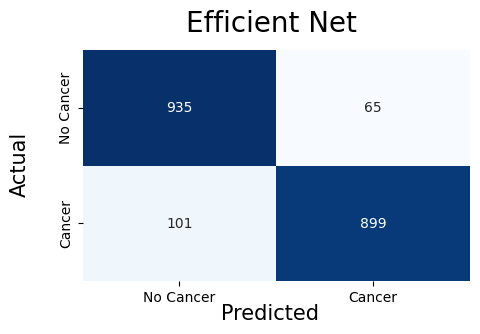

In [36]:
fig, axes = plt.subplots(1, 1, figsize=(5, 3))
ax1 = plt.subplot(1, 1, 1)

sns.heatmap(confusion, cmap="Blues", annot = True, fmt="d", cbar =False)

fig.text(0.5, 0.00, 
         'Predicted', 
         ha='center', 
         va='center', 
         fontsize = 15)
fig.text(0.00, 0.5, 
         'Actual',
         ha='center', 
         va='center', 
         rotation='vertical', 
         fontsize = 15)

ax1.text(0.5, 1.08, 'Efficient Net ',
    horizontalalignment='center',
    fontsize=20,
    transform = ax1.transAxes)

print("cell executed: ", date.today())

In [37]:
import numpy as np

test_pred_proba = np.array(test_pred_proba)
test_actuals = np.array(test_actuals)

print("cell executed: ", date.today())


cell executed:  2026-03-16


In [38]:
y_true = test_actuals
y_score = test_pred_proba[:, 1]  # column 1 = cancer probabilities

fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc_score_val = roc_auc_score(y_true, y_score)
print("AUC (Test Set):", round(roc_auc_score_val, 2))

print("cell executed: ", date.today())

AUC (Test Set): 0.97
cell executed:  2026-03-16


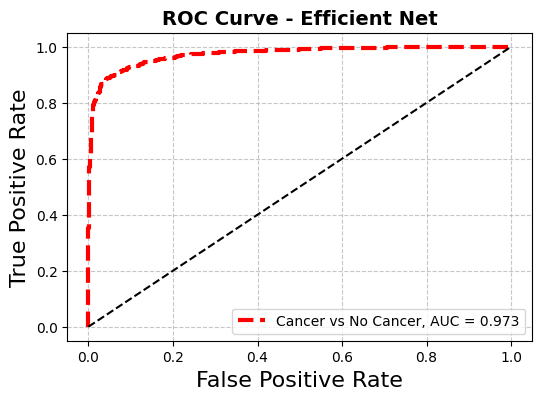

cell executed:  2026-03-16


In [39]:
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='red', lw=3, linestyle='--',
         label=f'Cancer vs No Cancer, AUC = {roc_auc_score_val:.3f}')
plt.plot([0, 1], [0, 1], color='black', lw=1.5, linestyle='--')

plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC Curve - Efficient Net', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("cell executed: ", date.today())

## PART 4: Costumized CNN - A Simple Efficient Net

Below there is an a customized Efficient Net build from scratch. 

In [40]:
img_size = (96, 96)
batch_size = 256
CHANNELS_IMG = 3

print("cell executed: ", date.today())

cell executed:  2026-03-16


In [41]:
class RawData(Dataset):
    def __init__(self, df, root_dir):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transforms.ToTensor()

    def __len__(self): 
        return len(self.df)
        
    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, f"{self.df.iloc[idx]['id']}.tif")
        img = Image.open(img_path).convert('RGB')
        return self.transform(img)

# stats
raw_df = RawData(train_df, '/kaggle/input/histopathologic-cancer-detection/train')
loader = DataLoader(raw_df, batch_size=64, shuffle=False, num_workers=4)

print("cell executed: ", date.today())


cell executed:  2026-03-16


In [42]:
mean, std, n_pixels = 0, 0, 0

for images in tqdm(loader, desc="stats processing"):
    batch_size, _, h, w = images.shape
    n_pixels += batch_size * h * w
    mean += images.sum([0, 2, 3])
    std += (images ** 2).sum([0, 2, 3])

mean /= n_pixels
std = torch.sqrt(std / n_pixels - mean ** 2)

mean = list(map(lambda num: round(num, 6), mean.tolist()))
std = list(map(lambda num: round(num, 6), std.tolist()))

print(f"Mean: {mean}")
print(f"Std : {std}")

print("cell executed: ", date.today())


stats processing: 100%|██████████| 94/94 [00:04<00:00, 22.46it/s]


Mean: [0.700685, 0.539182, 0.694069]
Std : [0.23371, 0.275289, 0.211138]
cell executed:  2026-03-16


In [43]:
#  normalize training data
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(), # random horizontal flip
    transforms.RandomVerticalFlip(), # random vertical flip
    transforms.RandomRotation(degrees=90),  # random 90 degree rotation
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std) 
])

# normalize validation data
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std) 
])

# normalize test data
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std) 
])

print("cell executed: ", date.today())


cell executed:  2026-03-16


In [44]:
%%time

train_dataset = CancerDataset(train_df, 
                              train_images_root_dir, 
                              transform=train_transform)

val_dataset = CancerDataset(val_df, 
                            train_images_root_dir, 
                            transform=val_transform)

test_dataset = CancerDataset(test_df, 
                             train_images_root_dir, 
                             transform=test_transform)

print("cell executed: ", date.today())


cell executed:  2026-03-16
CPU times: user 3.15 ms, sys: 5.89 ms, total: 9.05 ms
Wall time: 8.74 ms


In [45]:
# first image in train dataset
image, label = train_dataset[0]
print("Image shape:", image.shape)
print("Label:", label)

print("cell executed: ", date.today())


Image shape: torch.Size([3, 96, 96])
Label: 1
cell executed:  2026-03-16


In [46]:
batch_size = 256

train_dl = DataLoader(train_dataset, 
                      batch_size=batch_size, 
                      shuffle=True, 
                      num_workers=4, 
                      pin_memory=True)

val_dl = DataLoader(val_dataset,
                    batch_size=batch_size,
                    shuffle=False,
                    num_workers=4,
                    pin_memory=True)

test_dl = DataLoader(test_dataset,
                     batch_size=batch_size,
                     shuffle=False,
                     num_workers=4,
                     pin_memory=True)

print("cell executed: ", date.today())


cell executed:  2026-03-16


In [47]:
train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
test_dl = DeviceDataLoader(test_dl, device)

print("cell executed: ", date.today())

cell executed:  2026-03-16


In [48]:
class MBConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, expand_ratio=4):
        super().__init__()

        hidden_dim = in_channels * expand_ratio
        self.use_residual = stride == 1 and in_channels == out_channels

        # 1x1 expansion
        self.expand = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, 1, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(inplace=True)
        )

        # depthwise convolution
        self.depthwise = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(inplace=True)
        )

        # projection
        self.project = nn.Sequential(
            nn.Conv2d(hidden_dim, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x):
        out = self.expand(x)
        out = self.depthwise(out)
        out = self.project(out)

        if self.use_residual:
            out = out + x

        return out

print("cell executed: ", date.today())


cell executed:  2026-03-16


In [49]:
class SimpleEfficientNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True)
        )

        # MBConv stages
        self.block1 = MBConvBlock(32, 64, stride=2)
        self.block2 = MBConvBlock(64, 128, stride=2)
        self.block3 = MBConvBlock(128, 256, stride=2)

        # Head
        self.head = nn.Sequential(
            nn.Conv2d(256, 512, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stem(x)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = self.head(x)

        x = self.avgpool(x)
        x = torch.flatten(x,1)
        x = self.fc(x)

        return x

print("cell executed: ", date.today())


cell executed:  2026-03-16


In [50]:
simple_model = SimpleEfficientNet(num_classes=2)

x = torch.randn(1, 3, 96, 96)  # batch, channel, width, height
out = simple_model(x)

print(out.shape)  # torch.Size([1, 2])
print("cell executed: ", date.today())

torch.Size([1, 2])
cell executed:  2026-03-16


In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    simple_model = nn.DataParallel(simple_model)
simple_model = simple_model.to(device)

print("cell executed: ", date.today())


Using 2 GPUs
cell executed:  2026-03-16


In [52]:
criterion = nn.CrossEntropyLoss()

# use Adam optimizer
optimizer = torch.optim.AdamW(
    simple_model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

# reduce learning rate by 5% on every epoch
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(simple_model.state_dict())
early_stop_counter = 0

train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    simple_model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    for inputs, labels in train_dl:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = simple_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
        predicted = outputs.argmax(dim=1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss /= len(train_dataset)
    train_acc = 100 * train_correct / train_total

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    simple_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_dl:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = simple_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            predicted = outputs.argmax(dim=1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
  
    val_loss /= len(val_dataset)
    val_acc = 100 * val_correct / val_total

    
    val_losses.append(val_loss)
    val_accs.append(val_acc)
        
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% - Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    scheduler.step()
    
    # early stopping check to prevent overfitting
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(simple_model.state_dict())
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

# will load best weights after training is done
simple_model.load_state_dict(best_model_wts)

print("cell executed: ", date.today())


Epoch 1/30 - Train Loss: 0.5036, Train Acc: 75.55% - Val Loss: 1.0398, Val Acc: 52.55%
Epoch 2/30 - Train Loss: 0.4376, Train Acc: 79.97% - Val Loss: 0.7470, Val Acc: 63.70%
Epoch 3/30 - Train Loss: 0.4145, Train Acc: 81.02% - Val Loss: 0.4439, Val Acc: 80.75%
Epoch 4/30 - Train Loss: 0.4062, Train Acc: 81.25% - Val Loss: 0.4160, Val Acc: 82.30%
Epoch 5/30 - Train Loss: 0.3988, Train Acc: 81.78% - Val Loss: 0.3833, Val Acc: 83.30%
Epoch 6/30 - Train Loss: 0.3883, Train Acc: 82.53% - Val Loss: 0.3711, Val Acc: 84.40%
Epoch 7/30 - Train Loss: 0.3783, Train Acc: 82.97% - Val Loss: 0.3725, Val Acc: 84.55%
Epoch 8/30 - Train Loss: 0.3776, Train Acc: 83.12% - Val Loss: 0.3603, Val Acc: 84.85%
Epoch 9/30 - Train Loss: 0.3680, Train Acc: 83.73% - Val Loss: 0.3500, Val Acc: 85.40%
Epoch 10/30 - Train Loss: 0.3581, Train Acc: 84.35% - Val Loss: 0.3546, Val Acc: 85.65%
Epoch 11/30 - Train Loss: 0.3630, Train Acc: 83.63% - Val Loss: 0.3490, Val Acc: 85.40%
Epoch 12/30 - Train Loss: 0.3603, Train A

In [53]:
simple_model.eval()
print("cell executed: ", date.today())

cell executed:  2026-03-16


In [54]:
training_stats = pd.DataFrame({"Training_Accuracy": train_accs,
                               "Training_Loss": train_losses,
                               "Val_Loss": val_losses,
                               "Val_Accuracy": val_accs})

n_epochs = len(training_stats)

print("cell executed: ", date.today())


cell executed:  2026-03-16


cell executed:  2026-03-16


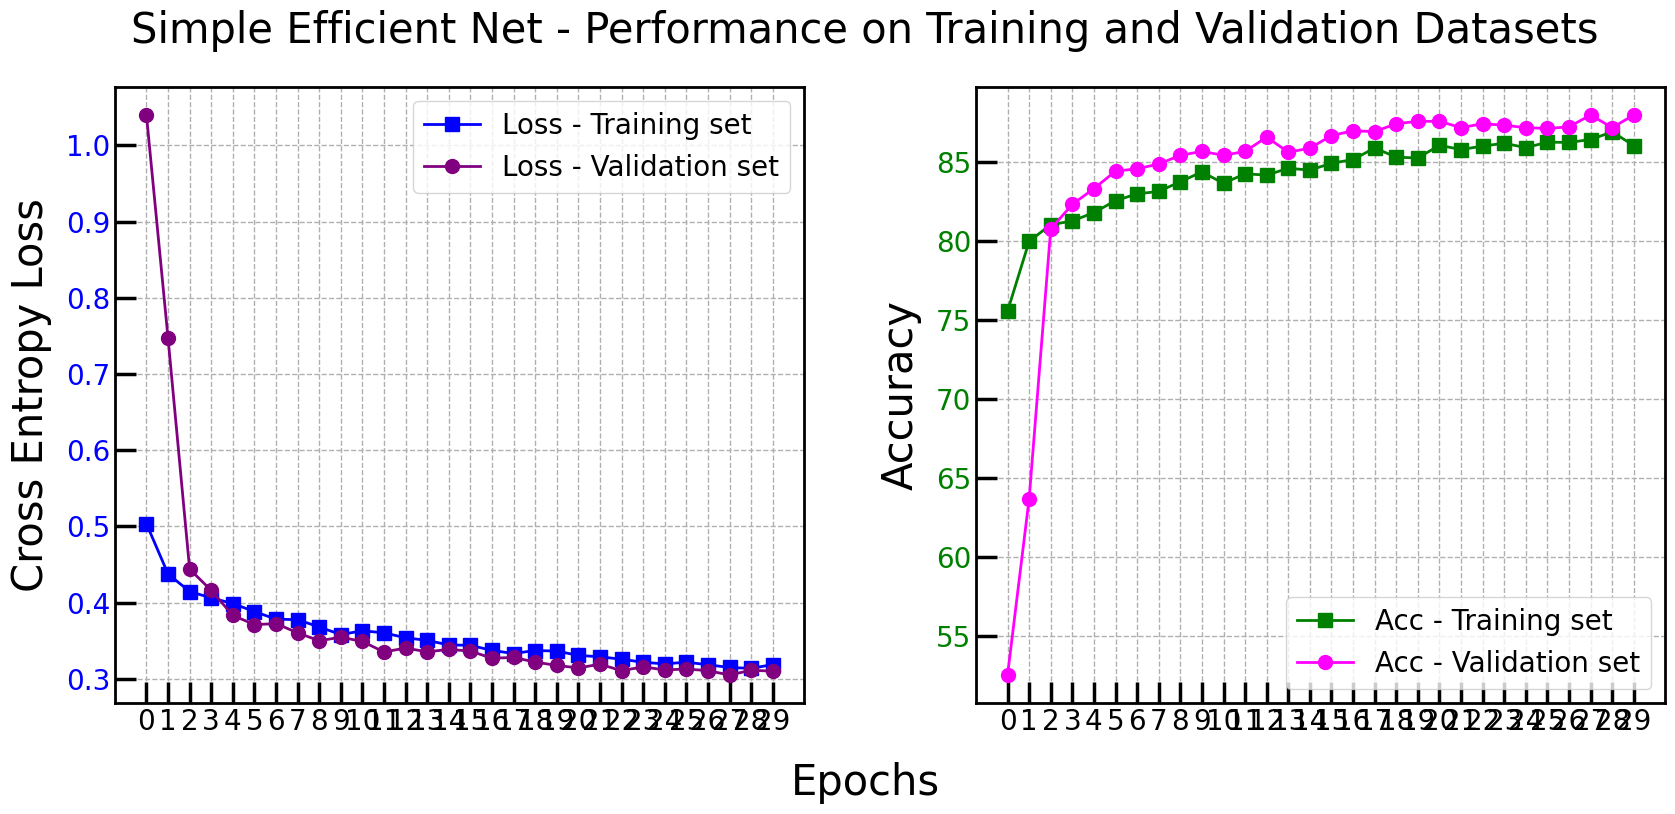

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
ax1 = plt.subplot(1,2, 1)

plot_1 = ax1.plot(range(n_epochs), 
                  training_stats['Training_Loss'], 
                  color = 'blue', 
                  label = 'Loss - Training set',
                  marker = 's',
                  linewidth=2.0,
                  markersize = 10)

plot_2 = ax1.plot(range(n_epochs),
                  training_stats['Val_Loss'],
                  color = 'purple',
                  label = 'Loss - Validation set',
                  marker = 'o',
                  linewidth=2.0,
                  markersize = 10)

ax1.legend(fontsize = 20)
plt.xticks(range(0, n_epochs, 1))
ax1.tick_params(axis ='y', labelcolor = 'blue',labelsize=20, width=3) 
ax1.tick_params(axis ='x', labelcolor = 'black',labelsize=20, width=3)
ax1.set_ylabel("Cross Entropy Loss", fontsize = 30, labelpad = 10, color = 'black')


ax1a = plt.subplot(1,2, 2)
plot_11 = ax1a.plot(range(n_epochs),
                    training_stats['Training_Accuracy'],
                    color = 'green',
                    label = 'Acc - Training set',
                    marker = 's',
                    linewidth=2.0,
                    markersize = 10)

plot_22 = ax1a.plot(range(n_epochs),
                    training_stats['Val_Accuracy'],
                    color = 'fuchsia',
                    label = 'Acc - Validation set',
                    marker = 'o',
                    linewidth=2.0,
                    markersize = 10)

ax1a.legend(fontsize = 20)
plt.xticks(range(0,n_epochs,1))
ax1a.tick_params(axis ='y', labelcolor = 'green',labelsize=20, width=3) 
ax1a.tick_params(axis ='x', labelcolor = 'black',labelsize=20, width=3)
ax1a.set_ylabel("Accuracy", fontsize = 30, labelpad = 10, color = 'black')

ax1.tick_params(which='both', width=2.5)
ax1.tick_params(which='major', length=15)
ax1.tick_params(which='minor', length=5)
ax1.tick_params(which = 'both', direction = 'in')

ax1a.tick_params(which='both', width=2.5)
ax1a.tick_params(which='major', length=15)
ax1a.tick_params(which='minor', length=5)
ax1a.tick_params(which = 'both', direction = 'in') 

ax1a.spines['bottom'].set_color('black')
ax1a.spines['top'].set_color('black') 
ax1a.spines['right'].set_color('black')
ax1a.spines['right'].set_linewidth(2)
ax1a.spines['top'].set_linewidth(2)
ax1a.spines['bottom'].set_linewidth(2)
ax1a.spines['left'].set_color('black')
ax1a.spines['left'].set_lw(2)

ax1.spines['bottom'].set_color('black')
ax1.spines['top'].set_color('black') 
ax1.spines['right'].set_color('black')
ax1.spines['right'].set_linewidth(2)
ax1.spines['top'].set_linewidth(2)
ax1.spines['bottom'].set_linewidth(2)
ax1.spines['left'].set_color('black')
ax1.spines['left'].set_lw(2)

ax1.grid(True, which = 'major', alpha = 1, linestyle='--', linewidth = 1)
ax1a.grid(True, which = 'major', alpha = 1, linestyle='--', linewidth = 1)

plt.subplots_adjust(wspace=0.25,hspace=0.)
fig.text(0.5, 0.01, 
         'Epochs', 
         ha='center', 
         va='center', 
         fontsize = 30)

fig.text(0.5, 0.95,
         'Simple Efficient Net - Performance on Training and Validation Datasets',
         ha='center', 
         va='center', 
         fontsize = 30)

print("cell executed: ", date.today())


In [56]:
train_actuals_simple, train_pred_simple, train_pred_proba_simple = get_test_predictions_with_probs(simple_model, train_dl)
val_actuals_simple, val_pred_simple, val_pred_proba_simple = get_test_predictions_with_probs(simple_model, val_dl)
test_actuals_simple, test_pred_simple, test_pred_proba_simple = get_test_predictions_with_probs(simple_model, test_dl)

print("cell executed: ", date.today())


100%|██████████| 8/8 [00:02<00:00,  3.55it/s]

cell executed:  2026-03-16


In [57]:
print("Classification report for training set")
print(classification_report(train_actuals_simple, train_pred_simple))

print("Classification report for validation set")
print(classification_report(val_actuals_simple, val_pred_simple))

print("Classification report for test set")
print(classification_report(test_actuals_simple, test_pred_simple))

print("cell executed: ", date.today())

Classification report for training set
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      3000
           1       0.89      0.85      0.87      3000

    accuracy                           0.87      6000
   macro avg       0.87      0.87      0.87      6000
weighted avg       0.87      0.87      0.87      6000

Classification report for validation set
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      1000
           1       0.88      0.88      0.88      1000

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000

Classification report for test set
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      1000
           1       0.87      0.85      0.86      1000

    accuracy                           0.86      2000
   macro avg 

In [58]:
# confusion matrix on test dataset
conf_matrix_simple = confusion_matrix(test_actuals_simple, test_pred_simple)

classes = list(index_to_labels_mapping.values())
confusion_simple = pd.DataFrame(conf_matrix_simple, 
                                index = classes, 
                                columns = classes)

print("Confusion matrix on test set for Simple Efficient Net:\n", confusion_simple)
print("cell executed: ", date.today())

Confusion matrix on test set for Simple Efficient Net:
            No Cancer  Cancer
No Cancer        868     132
Cancer           145     855
cell executed:  2026-03-16


cell executed:  2026-03-16


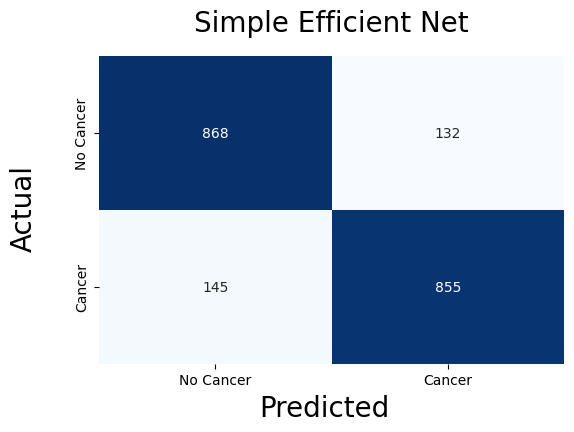

In [59]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))
ax1 = plt.subplot(1, 1, 1)

sns.heatmap(confusion_simple, cmap="Blues", annot = True, fmt="d", cbar =False)

fig.text(0.5, 0.00, 'Predicted', ha='center', va='center', fontsize = 20)
fig.text(0.0, 0.5, 'Actual', ha='center', va='center', rotation='vertical', fontsize = 20)
ax1.text(0.5, 1.08, 'Simple Efficient Net',
    horizontalalignment='center',
    fontsize=20,
    transform = ax1.transAxes);

print("cell executed: ", date.today())


In [60]:
test_pred_proba_simple = np.array(test_pred_proba_simple)
test_actuals_simple = np.array(test_actuals_simple)

y_true_s = test_actuals_simple
y_score_s = test_pred_proba_simple[:, 1]  # column 1 = cancer probabilities

fpr_s, tpr_s, thresholds_s = roc_curve(y_true_s, y_score_s)
roc_auc_score_value_s = roc_auc_score(y_true_s, y_score_s)
print("AUC (Test Set):", round(roc_auc_score_value_s, 3))

print("cell executed: ", date.today())


AUC (Test Set): 0.935
cell executed:  2026-03-16


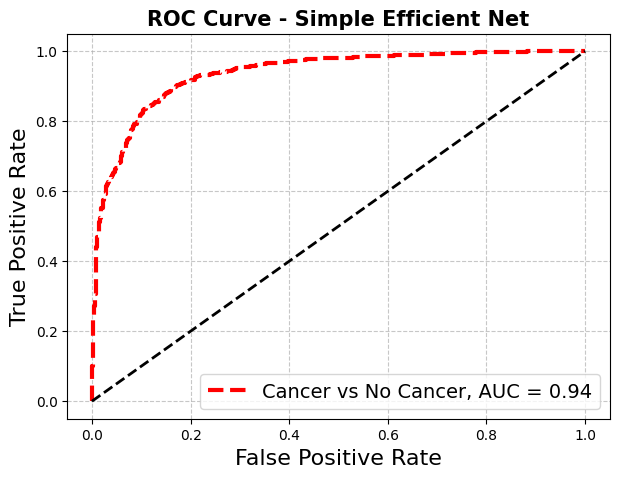

cell executed:  2026-03-16


In [61]:
plt.figure(figsize=(7, 5))
plt.plot(fpr_s, tpr_s, 
         color='red', 
         lw=3, 
         linestyle='--',
         label=f'Cancer vs No Cancer, AUC = {roc_auc_score_value_s:.2f}')

plt.plot([0, 1], [0, 1], 
         color='black', 
         lw=2, 
         linestyle='--')

plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC Curve - Simple Efficient Net', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("cell executed: ", date.today())

# Conclusion

We train two models: 

    1. Efficient Net with pre-trained weights, Adam Optimizer, and step-decay Learning Rate scheduling - AUC (Test Set): 0.97
    2. Custom Efficient Net with PyTorch, Adam optimizer, and exponential-decay Learning Rate scheduling - AUC (Test Set): 0.93

The training is done with data augmentation, i.e. random rotation and horizontal/vertical flip.


In [62]:
print("END CODE")

END CODE


# Submission of Efficient Net predictions to Kaggle

In [64]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

test_dir = "/kaggle/input/histopathologic-cancer-detection/test"

transform = transforms.Compose([
    transforms.Resize((96,96)),
    transforms.ToTensor()
])

class TestDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        self.files = os.listdir(folder)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_name = self.files[idx]
        path = os.path.join(self.folder, img_name)

        image = Image.open(path)

        if self.transform:
            image = self.transform(image)

        return image, img_name.split(".")[0]


test_dataset = TestDataset(test_dir, transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("cell executed: ", date.today())


cell executed:  2026-03-16


In [65]:
model.eval()

ids = []
preds = []

with torch.no_grad():
    for images, img_ids in test_loader:
        images = images.to(device)

        outputs = model(images)

        # Convert logits to probability of class 1 (cancer)
        probs = torch.softmax(outputs, dim=1)[:,1].cpu().numpy()

        ids.extend(img_ids)
        preds.extend(probs)

In [66]:
print("ids:", len(ids))
print("preds:", len(preds))

ids: 57458
preds: 57458


In [67]:
submission = pd.DataFrame({
    "id": ids,
    "label": preds
})

submission.to_csv("/kaggle/working/submission.csv", index=False)

print("Submission file created!")

Submission file created!


In [68]:
print(os.listdir("/kaggle/working"))

['submission.csv', '.virtual_documents']


In [69]:
submission.head()

,id,label
0,a7ea26360815d8492433b14cd8318607bcf99d9e,0.359284
1,59d21133c845dff1ebc7a0c7cf40c145ea9e9664,0.007404
2,5fde41ce8c6048a5c2f38eca12d6528fa312cdbb,0.217359
3,bd953a3b1db1f7041ee95ff482594c4f46c73ed0,0.128623
4,523fc2efd7aba53e597ab0f69cc2cbded7a6ce62,0.227332
